This code is loosely based on: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

# Download and visualize the dataset

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Transform the images, e.g., flip or rotate
# See https://pytorch.org/vision/stable/auto_examples/plot_transforms.html
# for more examples.
train_transforms = transforms.Compose(
    [
     transforms.RandomHorizontalFlip(p=0.5), # randomly flip image horizontally
     transforms.RandomVerticalFlip(p=0.2), # randomly flip image vertically
     transforms.ColorJitter(brightness=0.1, hue=0.1, contrast=0.05), # change the colors slightly
     transforms.ToTensor(), # convert image into a tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # this puts the images pixel values to [-1, 1] range
    ])

test_transforms = transforms.Compose(
    [
     transforms.ToTensor(), # convert image into a tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # this puts the images pixel values to [-1, 1] range
    ])

trainset = torchvision.datasets.CIFAR10(
                                      root='./data',
                                      train=True,
                                      download=True,
                                      transform=train_transforms
                                    )
testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=test_transforms
                                       )

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')



100%|██████████| 170M/170M [00:02<00:00, 75.2MB/s]


In [ ]:
def create_data_loaders(batch_size):
  trainloader = torch.utils.data.DataLoader(trainset,
                                            batch_size=batch_size,
                                            shuffle=True,
                                            num_workers=2
                                            )


  testloader = torch.utils.data.DataLoader(testset,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2
                                          )
  return trainloader, testloader
batch_size = 4
trainloader, testloader = create_data_loaders(batch_size)

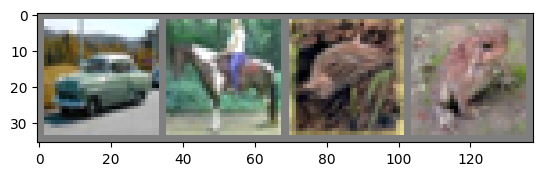

car   horse bird  frog 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some training images
dataiter = iter(trainloader)
images, labels = next(dataiter)


# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

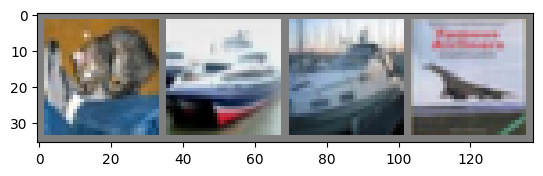

cat   ship  ship  plane


In [ ]:
# get some test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## Build the model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.drop_out = nn.Dropout(0.75)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.drop_out(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net() # randomly initialized (i.e., according to pytorch standard initialization)
net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (drop_out): Dropout(p=0.75, inplace=False)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
import torch
net(torch.zeros(1,3,32,32)) # scores for each of the ten classes we are predicting

tensor([[-0.0599,  0.0991, -0.0102,  0.0015, -0.0009, -0.0018, -0.0274,  0.0026,
         -0.0916, -0.0155]], grad_fn=<AddmmBackward0>)

In [ ]:
net(images)

tensor([[-0.0430,  0.1207,  0.0071, -0.0070, -0.0046,  0.0122,  0.0027, -0.0167,
         -0.0976, -0.0117],
        [-0.0541,  0.1081, -0.0002, -0.0203,  0.0317,  0.0068,  0.0037,  0.0039,
         -0.0999, -0.0146],
        [-0.0533,  0.1010, -0.0235,  0.0122,  0.0142, -0.0123, -0.0249, -0.0126,
         -0.0987,  0.0002],
        [-0.0423,  0.1171, -0.0149,  0.0078,  0.0345,  0.0348, -0.0251, -0.0270,
         -0.1338, -0.0160]], grad_fn=<AddmmBackward0>)

In [ ]:
for i in range(4):
  print(classes[net(images)[i,:].argmax()]) # predictions of **untrained** neural network

car
car
car
car


# Train the model

In [ ]:
import time, math

criterion = nn.CrossEntropyLoss()
def train(net, optimizer, trainloader, batch_size, number_of_epochs):
  t0 = time.time()
  for epoch in range(number_of_epochs):  # loop over the dataset multiple times
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
          # each loop here is sampling a new batch of four data points
          # get the inputs; data is a list of [inputs, labels]
          inputs, labels = data

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          scores = net(inputs)
          loss = criterion(scores, labels)
          loss.backward()
          optimizer.step()

          # Print statistics on the observed loss function
          # this allows us to get a realtime estimate of how
          # well training is going.
          running_loss += loss.item()
          print_every_n_batches = math.ceil(4000 / batch_size)
          if i % print_every_n_batches == print_every_n_batches - 1:    # print every 4000 data points
              avg_loss = running_loss / print_every_n_batches
              print(f'[{epoch + 1}, {i + 1:5d}] loss: {avg_loss:.3f}')
              running_loss = 0.0 # reset observed loss function
  t1 = time.time()
  print('Finished training after ', str(t1 - t0), ' seconds')

In [ ]:
batch_size

4

In [ ]:
import torch.optim as optim

net = Net()
optimizer = optim.SGD(net.parameters(), lr=0.005)
number_of_epochs = 2
train(net, optimizer, trainloader, batch_size, number_of_epochs)

[1,  1000] loss: 2.302
[1,  2000] loss: 2.296
[1,  3000] loss: 2.264
[1,  4000] loss: 2.192
[1,  5000] loss: 2.103
[1,  6000] loss: 2.071
[1,  7000] loss: 2.049
[1,  8000] loss: 1.994
[1,  9000] loss: 1.959
[1, 10000] loss: 1.930
[1, 11000] loss: 1.933
[1, 12000] loss: 1.894
[2,  1000] loss: 1.857
[2,  2000] loss: 1.846
[2,  3000] loss: 1.828
[2,  4000] loss: 1.856
[2,  5000] loss: 1.818
[2,  6000] loss: 1.797
[2,  7000] loss: 1.791
[2,  8000] loss: 1.781
[2,  9000] loss: 1.784
[2, 10000] loss: 1.727
[2, 11000] loss: 1.746
[2, 12000] loss: 1.713
Finished training after  196.32690334320068  seconds


In [ ]:
net.eval() # evaluation mode, turns off drop out
for i in range(4):
  print(classes[net(images)[i,:].argmax()]) # predictions of **trained** neural network

dog
ship
ship
ship


In [ ]:
def compute_accuracy(net, testloader):
  correct = 0
  total = 0
  # since we're not training, we don't need to calculate the gradients for our outputs
  with torch.no_grad():
      for data in testloader:
          images, labels = data
          # calculate outputs by running images through the network
          outputs = net(images)
          # the class with the highest scores is what we choose as prediction
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')
compute_accuracy(net, testloader)

Accuracy of the network on the 10000 test images: 41 %


## Train the model with a bigger batch size

In [ ]:
import torch.optim as optim
import math

batch_size = 256
trainloader, testloader = create_data_loaders(batch_size)
criterion = nn.CrossEntropyLoss()

net = Net()
optimizer = optim.SGD(net.parameters(), lr=0.4)

number_of_epochs = 2
train(net, optimizer, trainloader, batch_size, number_of_epochs)

[1,    16] loss: 2.302
[1,    32] loss: 2.273
[1,    48] loss: 2.224
[1,    64] loss: 2.158
[1,    80] loss: 2.166
[1,    96] loss: 2.206
[1,   112] loss: 2.133
[1,   128] loss: 2.126
[1,   144] loss: 2.066
[1,   160] loss: 2.069
[1,   176] loss: 2.030
[1,   192] loss: 1.996
[2,    16] loss: 2.160
[2,    32] loss: 2.062
[2,    48] loss: 2.054
[2,    64] loss: 2.039
[2,    80] loss: 2.007
[2,    96] loss: 2.019
[2,   112] loss: 1.977
[2,   128] loss: 1.939
[2,   144] loss: 1.951
[2,   160] loss: 1.934
[2,   176] loss: 1.930
[2,   192] loss: 1.930
Finished training after  85.95558524131775  seconds


In [ ]:
net.eval() # evaluation mode, turns off drop out
for i in range(4):
  print(classes[net(images)[i,:].argmax()]) # predictions of **trained** neural network

truck
car
car
car


In [ ]:
compute_accuracy(net, testloader)

Accuracy of the network on the 10000 test images: 33 %


## Train the model with a full batch SGD

In [ ]:
import torch.optim as optim
import math

batch_size = 60000
trainloader, testloader = create_data_loaders(batch_size)
criterion = nn.CrossEntropyLoss()

net = Net()
optimizer = optim.SGD(net.parameters(), lr=10.0)

number_of_epochs = 2
train(net, optimizer, trainloader, batch_size, number_of_epochs)

[1,     1] loss: 2.305
[2,     1] loss: 2.301
Finished training after  131.65013194084167  seconds


In [ ]:
net.eval()
compute_accuracy(net, testloader)

Accuracy of the network on the 10000 test images: 14 %


## Tune the step size

One strategy is to tune the learning rate using a small number of epochs and then once we have found a good learning rate we run for more epochs

In [ ]:
lr_list = [0.01, 0.1, 1.0, 10.0]
batch_size = 64
for lr in lr_list:
  print("learning rate = ", lr)
  net = Net()
  optimizer = optim.SGD(net.parameters(), lr=lr)
  number_of_epochs = 1
  trainloader, testloader = create_data_loaders(batch_size)
  train(net, optimizer, trainloader, batch_size, number_of_epochs)
  compute_accuracy(net, testloader)

learning rate =  0.01
[1,    63] loss: 2.304
[1,   126] loss: 2.305
[1,   189] loss: 2.303
[1,   252] loss: 2.301
[1,   315] loss: 2.300
[1,   378] loss: 2.301
[1,   441] loss: 2.299
[1,   504] loss: 2.298
[1,   567] loss: 2.295
[1,   630] loss: 2.295
[1,   693] loss: 2.293
[1,   756] loss: 2.289
Finished training after  47.15156960487366  seconds
Accuracy of the network on the 10000 test images: 15 %
learning rate =  0.1
[1,    63] loss: 2.302
[1,   126] loss: 2.296
[1,   189] loss: 2.221
[1,   252] loss: 2.129
[1,   315] loss: 2.086
[1,   378] loss: 2.063
[1,   441] loss: 2.034
[1,   504] loss: 2.004
[1,   567] loss: 1.956
[1,   630] loss: 1.939
[1,   693] loss: 1.932
[1,   756] loss: 1.921
Finished training after  47.26944375038147  seconds
Accuracy of the network on the 10000 test images: 24 %
learning rate =  1.0
[1,    63] loss: 2.370
[1,   126] loss: 2.308
[1,   189] loss: 2.307
[1,   252] loss: 2.306
[1,   315] loss: 2.305
[1,   378] loss: 2.306
[1,   441] loss: 2.306
[1,   504

## Run the best learning rate for more epochs

In [ ]:
net = Net()
batch_size = 64
optimizer = optim.SGD(net.parameters(), lr=0.1)
number_of_epochs = 10
trainloader, testloader = create_data_loaders(batch_size)
train(net, optimizer, trainloader, batch_size,number_of_epochs)

[1,    63] loss: 2.303
[1,   126] loss: 2.290
[1,   189] loss: 2.208
[1,   252] loss: 2.119
[1,   315] loss: 2.092
[1,   378] loss: 2.060
[1,   441] loss: 2.054
[1,   504] loss: 1.976
[1,   567] loss: 1.962
[1,   630] loss: 1.942
[1,   693] loss: 1.913
[1,   756] loss: 1.896
[2,    63] loss: 1.863
[2,   126] loss: 1.869
[2,   189] loss: 1.843
[2,   252] loss: 1.838
[2,   315] loss: 1.822
[2,   378] loss: 1.814
[2,   441] loss: 1.789
[2,   504] loss: 1.786
[2,   567] loss: 1.768
[2,   630] loss: 1.745
[2,   693] loss: 1.730
[2,   756] loss: 1.741
[3,    63] loss: 1.734
[3,   126] loss: 1.734
[3,   189] loss: 1.710
[3,   252] loss: 1.719
[3,   315] loss: 1.716
[3,   378] loss: 1.679
[3,   441] loss: 1.688
[3,   504] loss: 1.685
[3,   567] loss: 1.678
[3,   630] loss: 1.674
[3,   693] loss: 1.670
[3,   756] loss: 1.664
[4,    63] loss: 1.662
[4,   126] loss: 1.644
[4,   189] loss: 1.658
[4,   252] loss: 1.678
[4,   315] loss: 1.634
[4,   378] loss: 1.642
[4,   441] loss: 1.638
[4,   504] 

In [ ]:
net.eval()
compute_accuracy(net, testloader)

Accuracy of the network on the 10000 test images: 52 %
